### Appendix B - Source Code {-}

## Data ingestion and class selection (Stage 1) {-}

### Environment and configuration (Step 1) {-}

Steps 1 and 1b configure the environment before data ingestion. The configuration block sets hyperparameters and random seeds for reproducibility. A helper `resolve_dataset_path` function downloads RadioML 2018.01A via kagglehub or uses a local path override if file present. The notebook then reads the HDF5 file with h5py, using groups X (I/Q frames), Y (one-hot labels), and Z (SNR) per O'Shea et al. (2018).

In [18]:
# Install required dependencies for the project
%pip install -U numpy h5py matplotlib scipy scikit-learn keras jax jaxlib kagglehub python-dotenv

/usr/lib/python3.14/pty.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.


In [19]:
import os
# Backend Configuration
# I use the JAX backend for Keras as discussed in Chollet and Watson, 2026.
os.environ.setdefault("KERAS_BACKEND", "jax")  

from dotenv import load_dotenv
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import stft
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import keras
from keras import layers
import kagglehub
import math

# Verify the setup
print(f"Keras version: {keras.__version__} | Backend: {keras.backend.backend()}")

# ------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------

# Load Kaggle API keys
load_dotenv()

# Authenticate with Kaggle to access the dataset
token = os.getenv("KAGGLE_API_TOKEN")
token_path = os.path.expanduser(os.getenv("KAGGLE_API_TOKEN_PATH", "~/.kaggle/access_token"))

# Set these for the Kaggle library to find automatically
os.environ["KAGGLE_API_TOKEN"] = token
os.environ["KAGGLE_API_TOKEN_PATH"] = token_path

# Dataset Source: DeepSig RadioML 2018.01A
KAGGLE_DATASET   = "pinxau1000/radioml2018" 
HDF5_FILENAME    = "GOLD_XYZ_OSC.0001_1024.hdf5"

# Allow overriding the path if already have the file locally (saves re-downloading)
RADIOML_PATH     = os.environ.get("RADIOML_PATH")

# ------------------------------------------------------------------
# TRAINING HYPERPARAMETERS
# ------------------------------------------------------------------

# Data Structure
FRAMES_PER_BLOCK = 106496   # Total frames per block (26 SNRs * 4096 frames/mod)
FRAMES_PER_CELL  = 4096     # Frames per (Modulation, SNR) pair
N_SNR            = 26       # Range: -20 dB to +30 dB in 2 dB steps

# Prototype subsample per cell
SAMPLES_PER_CELL = 200      

# Image Resolution
IMG_SIZE         = 128       

# Batch size for training and evaluation
# Process 32 samples at a time. Default for image processing (Chollet and Watson, 2026) is 64, 
# but I reduced it to 32 to avoid OOM errors on my hardware.
BATCH_SIZE       = 32

# Setting seeds ensures that random splits and weight initializations are identical every time
SEED             = 42       
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

# ------------------------------------------------------------------
# EXECUTION: Check Local Path
# ------------------------------------------------------------------
if RADIOML_PATH and not os.path.exists(RADIOML_PATH):
    print(f"Warning: Local path specified but file not found: {RADIOML_PATH}")
    RADIOML_PATH = None

print(f"\nConfiguration Loaded:")
print(f"- Dataset: RadioML 2018.01A ({KAGGLE_DATASET})")
print(f"- Target Size: {IMG_SIZE}x{IMG_SIZE} spectrograms")
print(f"- Subsample Count: ~{SAMPLES_PER_CELL * 8 * N_SNR} frames")
print(f"- Random Seed: {SEED}")

Keras version: 3.15.1 | Backend: jax

Configuration Loaded:
- Dataset: RadioML 2018.01A (pinxau1000/radioml2018)
- Target Size: 128x128 spectrograms
- Subsample Count: ~41600 frames
- Random Seed: 42


### Acquire the dataset from Kaggle (Step 1b) {-}

Each modulation class contains one contiguous block of 106,496 frames, 26 SNR levels of 4,096 frames each.

In [20]:
# ------------------------------------------------------------------
# DATA SET SETUP
# ------------------------------------------------------------------

def resolve_dataset_path():
    # If 'RADIOML_PATH' is already set in the environment, I use that location first.
    if RADIOML_PATH and os.path.exists(RADIOML_PATH):
        print(f"[INFO] Using local dataset override: {RADIOML_PATH}")
        return RADIOML_PATH
    
    # If no local path is set, download from Kaggle.
    # kagglehub caches the dataset under ~/.cache/kagglehub automatically.
    # This ensures the heavy 21.5 GB pull happens only once per machine.
    try:
        folder = kagglehub.dataset_download(KAGGLE_DATASET)
        
        # Search recursively for the specific HDF5 file within the downloaded folder
        hits = glob.glob(os.path.join(folder, "**", HDF5_FILENAME), recursive=True)
        
        if not hits:
            raise FileNotFoundError(
                f"Required file '{HDF5_FILENAME}' not found in downloaded content."
            )
        
        path = hits[0]
        print(f"[INFO] Using Kaggle dataset (cached): {path}")
        return path
        
    except Exception as e:
        # Provide guidance if authentication fails
        raise RuntimeError(
            "Failed to download dataset. Please check:\n"
            "1. Kaggle API Token is valid (~/.kaggle/kaggle.json)\n"
            "2. Environment variables KAGGLE_USERNAME/KAGGLE_KEY are set\n"
            f"Original Error: {str(e)}"
        )

# ------------------------------------------------------------------
# EXECUTION: Resolve Dataset Path
# ------------------------------------------------------------------
DATASET_PATH = resolve_dataset_path()
print(f"\n[SUCCESS] Dataset ready at: {DATASET_PATH}")

[INFO] Using local dataset override: /home/yshulm01/.cache/kagglehub/datasets/pinxau1000/radioml2018/versions/2/GOLD_XYZ_OSC.0001_1024.hdf5

[SUCCESS] Dataset ready at: /home/yshulm01/.cache/kagglehub/datasets/pinxau1000/radioml2018/versions/2/GOLD_XYZ_OSC.0001_1024.hdf5


### Load RadioML 2018.01A and select the eight classes (Step 2) {-}

Step 2 reduces the (modulation, SNR) cell to a simple slice to gather the eight chosen classes. This reduction from 24 to 8 classes minimizes low-SNR ambiguity that even hybrid CNN+SVM models struggle with (Abd-Elaziz et al., 2023; Nasir et al., 2025) while maintaining the geometric complexity progression aligned with O'Shea et al. (2018). For the prototype, Step 2 explicitly limits samples per cell to keep training within a reasonable time budget, addressing design risks.

In [21]:
# ------------------------------------------------------------------
# MODULATION CLASS SELECTION
# ------------------------------------------------------------------

# Base classes from RadioML 2018.01A paper [O'Shea et al., 2018].
# This list contains all 24 modulation schemes available in the dataset.
base_modulation_classes = [
    'OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK',
    '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM',
    '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC',
    'FM', 'GMSK', 'OQPSK'
]

# I reduced the set from 24 to 8 classes: 
selected_modulation_classes = ['4ASK', 'BPSK', 'QPSK', '16PSK', '16QAM', 'FM', 'AM-DSB-WC', '32APSK']

# Map selected names to their original integer IDs in the dataset
selected_ids = [base_modulation_classes.index(c) for c in selected_modulation_classes]

print(f"Selected {len(selected_ids)} classes out of {len(base_modulation_classes)}:")
print(f"IDs: {selected_ids}")
print(f"Classes: {selected_modulation_classes}")

# ------------------------------------------------------------------
# DATA LOADING FUNCTION
# ------------------------------------------------------------------

def load_cells(path, mod_ids, samples_per_cell):
    X, y, snr = [], [], []
    
    print(f"\nLoading data for {len(mod_ids)} classes...")
    
    with h5py.File(path, "r") as f:
        # Loop through each chosen modulation class
        for new_label, mid in enumerate(mod_ids):
            
            # Loop through each SNR level (-20 dB to +30 dB)
            for s in range(N_SNR):
                
                # Calculate start index for specific (modulation, SNR) cell
                start = mid * FRAMES_PER_BLOCK + s * FRAMES_PER_CELL
                
                # Randomly select 'samples_per_cell' frames without replacement
                pick = np.sort(np.random.choice(FRAMES_PER_CELL, samples_per_cell, replace=False))
                
                # Compute global indices
                idx = (start + pick).tolist()
                
                # Load Data
                # f['X']: I/Q samples (shape: N, 1024, 2)
                # f['Z']: SNR values
                X.append(f['X'][idx])             
                snr.append(f['Z'][idx].ravel())   
                
                # Create Labels (0 to len(mod_ids)-1)
                y.append(np.full(samples_per_cell, new_label))
    
    # Combine all lists into single NumPy arrays
    # X: (Total_Samples, 1024, 2)
    # y: (Total_Samples,)
    # snr: (Total_Samples,)
    return np.concatenate(X), np.concatenate(y), np.concatenate(snr)

# ------------------------------------------------------------------
# EXECUTION: Load Prototype Dataset
# ------------------------------------------------------------------

# Load the subsampled data using the defined parameters
X_iq, y_int, snr = load_cells(DATASET_PATH, selected_ids, SAMPLES_PER_CELL)

# Verify dimensions
print(f"\nData Loaded:")
print(f"- I/Q Tensor Shape: {X_iq.shape}  (Samples, Time, I/Q)")
print(f"- Labels Shape:     {y_int.shape}")
print(f"- Unique SNR Levels: {np.unique(snr)}")
print(f"- Total Samples:    {X_iq.shape[0]}")

Selected 8 classes out of 24:
IDs: [1, 3, 4, 6, 12, 21, 19, 9]
Classes: ['4ASK', 'BPSK', 'QPSK', '16PSK', '16QAM', 'FM', 'AM-DSB-WC', '32APSK']

Loading data for 8 classes...

Data Loaded:
- I/Q Tensor Shape: (41600, 1024, 2)  (Samples, Time, I/Q)
- Labels Shape:     (41600,)
- Unique SNR Levels: [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]
- Total Samples:    41600


### Balanced train and validation (Step 3) {-}

Step 3 first filters the dataset to SNR ≥ -2 dB following performance evaluation per noise level of the base model, following Waqas et al. (2023) who restricted evaluation to SNR > 5 dB and achieved 91.2% accuracy. Below this threshold, constellation points overlap at the symbol level and no spectrogram representation can reliably separate QPSK from 16PSK or 16QAM from 32APSK — the samples are intrinsically ambiguous. Removing them allows the model to focus capacity on the regime where spectral features are discriminative.

The filtered indices are then split into training, validation, and test sets balanced by (modulation, SNR) pairs, ensuring every retained SNR level appears in all three sets. This follows Chollet and Watson's (2026) protocol and enables SNR-resolved evaluation in Stage 4.

In [22]:
# ------------------------------------------------------------------
# SNR FILTER: retain only SNR >= -2 dB (follows Waqas et al. 2023)
# ------------------------------------------------------------------
SNR_THRESHOLD = -2
filtered_indices = np.where(snr >= SNR_THRESHOLD)[0]
y_int_filt = y_int[filtered_indices]
snr_filt   = snr[filtered_indices]

print(f"SNR filter (>= {SNR_THRESHOLD} dB): {len(filtered_indices):,} / {len(snr):,} samples retained")
print(f"Retained SNR levels: {np.unique(snr_filt)}")

# ------------------------------------------------------------------
# DATA SPLITTING (on filtered global indices)
# ------------------------------------------------------------------

# stratify key preserves (modulation, SNR) balance across all three sets
stratify_key = [f"{a}_{b}" for a, b in zip(y_int_filt, snr_filt)]

# Split positions within filtered_indices, then map back to global positions
# so idx_train / idx_val / idx_test can directly index img_paths, y_int, snr.
pos_all = np.arange(len(filtered_indices))

pos_train, pos_tmp = train_test_split(
    pos_all,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_key
)

stratify_tmp = [stratify_key[i] for i in pos_tmp]
pos_val, pos_test = train_test_split(
    pos_tmp,
    test_size=0.50,
    random_state=SEED,
    stratify=stratify_tmp
)

idx_train = filtered_indices[pos_train]
idx_val   = filtered_indices[pos_val]
idx_test  = filtered_indices[pos_test]

# ------------------------------------------------------------------
# EXECUTION: Confirm Dataset Sizes and SNR Coverage
# ------------------------------------------------------------------
print("\nFinal Dataset Sizes")
total = len(filtered_indices)
print(f"Training Set:   {len(idx_train):,} samples (~{len(idx_train)/total*100:.1f}%)")
print(f"Validation Set: {len(idx_val):,} samples (~{len(idx_val)/total*100:.1f}%)")
print(f"Test Set:       {len(idx_test):,} samples (~{len(idx_test)/total*100:.1f}%)")

def check_snr_coverage(indices, name):
    subset_snr = snr[indices]
    print(f"{name} SNR Range: [{subset_snr.min():.0f}, {subset_snr.max():.0f}] dB")

check_snr_coverage(idx_train, "Train")
check_snr_coverage(idx_val,   "Val  ")
check_snr_coverage(idx_test,  "Test ")

SNR filter (>= -2 dB): 27,200 / 41,600 samples retained
Retained SNR levels: [-2  0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30]

Final Dataset Sizes
Training Set:   19,040 samples (~70.0%)
Validation Set: 4,080 samples (~15.0%)
Test Set:       4,080 samples (~15.0%)
Train SNR Range: [-2, 30] dB
Val   SNR Range: [-2, 30] dB
Test  SNR Range: [-2, 30] dB


### Stage 1 Result {-}

The run loaded 41,600 I/Q frames (200 samples per (modulation, SNR) cell across eight classes and 26 SNR levels). After applying the final-model filter SNR ≥ −2 dB, 27,200 samples across 17 SNR levels remained. The balanced split yielded 19,040 training, 4,080 validation, and 4,080 test frames, with every retained SNR level present in each set. The earlier 49.47% result used a separate full-range baseline.

Replace Pre-allocation with a Keras Data Generator
Never materialize X_img at all. Generate spectrograms on-demand per batch during training:

In [23]:
class SpectrogramSequence(keras.utils.Sequence):
    def __init__(self, iq_data, labels, batch_size=BATCH_SIZE, **kwargs):
        super().__init__(**kwargs)
        self.iq_data = iq_data
        self.labels = labels
        self.batch_size = batch_size

    def __len__(self):
        return math.ceil(len(self.iq_data) / self.batch_size)

    def __getitem__(self, idx):
        lo = idx * self.batch_size
        hi = lo + self.batch_size
        X = np.stack([to_spectrogram(f) for f in self.iq_data[lo:hi]])
        return X, self.labels[lo:hi]

## STFT spectrogram preprocessing (Stage 2) {-}

### STFT spectrogram transform (Step 4) {-}

Step 4 converts every 1024-sample complex I/Q frame into a log-magnitude STFT image, the input modality established by Waqas et al. (2023). Log-magnitude was chosen because radio signals span wide energy ranges. Without it, strong signal components would dominate while weak details become invisible. The logarithm compresses this range, allowing simultaneous visibility of strong and weak signal features for easier pattern recognition.

In [24]:
# ------------------------------------------------------------------
# SPECTROGRAM GENERATION PIPELINE
# ------------------------------------------------------------------

def to_spectrogram(iq, nperseg=128, noverlap=112):
    # I/Q data is combined into one complex signal.
    x = iq[:, 0] + 1j * iq[:, 1] 

    # Short-Time Fourier Transform (STFT):
    _, _, Z = stft(x, window='hann', nperseg=nperseg, noverlap=noverlap,
                   return_onesided=False, boundary=None, padded=False)

    # Center Zero Frequency:
    Z_shifted = np.fft.fftshift(Z, axes=0)
    S = np.abs(Z_shifted) 

    # Channel R: log-magnitude spectrogram
    R_raw = 20.0 * np.log10(S + 1e-12)
    R = (R_raw - R_raw.min()) / (R_raw.max() - R_raw.min() + 1e-12)

    # Channel G: instantaneous frequency — dφ/dt along time axis.
    # Edge-pad (repeat first diff) so the first frame carries real signal
    # rather than a structural zero the model learns to ignore.
    phi_t = np.unwrap(np.angle(Z_shifted), axis=1)
    d_phi_t = np.diff(phi_t, axis=1)
    IF = np.concatenate([d_phi_t[:, :1], d_phi_t], axis=1)
    if_lo, if_hi = np.percentile(IF, 1), np.percentile(IF, 99)
    IF = np.clip(IF, if_lo, if_hi)
    IF = (IF - if_lo) / (if_hi - if_lo + 1e-12)

    # Channel B: spectral flux — d(log-mag)/dt along time axis (amplitude velocity).
    # Captures energy-transition dynamics: FM sweep band, PSK/QAM symbol transitions.
    # Fisher ratio at +30 dB is 23% higher than group delay; visually structured vs GD noise.
    d_R = np.diff(R_raw, axis=1)
    SF = np.concatenate([d_R[:, :1], d_R], axis=1)
    sf_lo, sf_hi = np.percentile(SF, 1), np.percentile(SF, 99)
    SF = np.clip(SF, sf_lo, sf_hi)
    SF = (SF - sf_lo) / (sf_hi - sf_lo + 1e-12)

    # resize STFT channels to square before stacking with non-STFT channels
    def _rsz(arr):
        t = arr[np.newaxis, :, :, np.newaxis]
        return np.asarray(keras.ops.image.resize(t, (IMG_SIZE, IMG_SIZE)))[0, :, :, 0]

    R, IF, SF = _rsz(R), _rsz(IF), _rsz(SF)

    # Channel 4: 2D IQ histogram — encodes constellation geometry directly.
    C, _, _ = np.histogram2d(iq[:, 0], iq[:, 1], bins=IMG_SIZE,
                              range=[[-2, 2], [-2, 2]], density=True)
    C = (C / (C.max() + 1e-12)).astype("float32")

    # Channel 5: phase clusters at N discrete angles for N-PSK/QAM.
    phi = np.angle(x)
    PH, _, _ = np.histogram2d(np.linspace(0, 1, len(phi)), phi,
                               bins=IMG_SIZE, range=[[0, 1], [-np.pi, np.pi]],
                               density=True)
    PH = (PH / (PH.max() + 1e-12)).astype("float32")

    return np.stack([R, IF, SF, C, PH], axis=-1).astype("float32")

def build_images(iq_batch, chunk_size=512):
    N = len(iq_batch)
    out = np.empty((N, IMG_SIZE, IMG_SIZE, 5), dtype="float32")
    for i in range(0, N, chunk_size):
        out[i:i + chunk_size] = np.stack([to_spectrogram(f) for f in iq_batch[i:i + chunk_size]])
    return out

# ------------------------------------------------------------------
# EXECUTION: Generate Spectrograms and One-Hot Labels
# ------------------------------------------------------------------

# Convert labels to one-hot encoding
y_oh = keras.utils.to_categorical(y_int, num_classes=len(selected_ids))

# Convert raw I/Q data to spectrograms generated on-the-fly during training using a custom Keras Sequence.
train_seq = SpectrogramSequence(X_iq[idx_train], y_oh[idx_train], batch_size=BATCH_SIZE)
val_seq   = SpectrogramSequence(X_iq[idx_val],   y_oh[idx_val],   batch_size=BATCH_SIZE)

### Visual sanity check (Step 5) {-}

Step 5 applies a Hann window, balancing time and frequency resolution with a preference for timing clarity per Zheng et al. (2025). Signal strength is converted to decibels, zero frequency is centred for readability (Clark and Clark, 2025), and min-max scaling is applied per image.

The final input is a 128×128 five-channel feature tensor. The four-block custom CNN uses this resolution to preserve detail for the digital classes. Waqas et al. (2023) demonstrated that lower-resolution spectrograms can reduce computational cost; this project increased resolution only after the original 64×64 representation left the digital classes confused. The notebook displays numerical feature maps with viridis for inspection; the model receives float32 channels, not display colours.

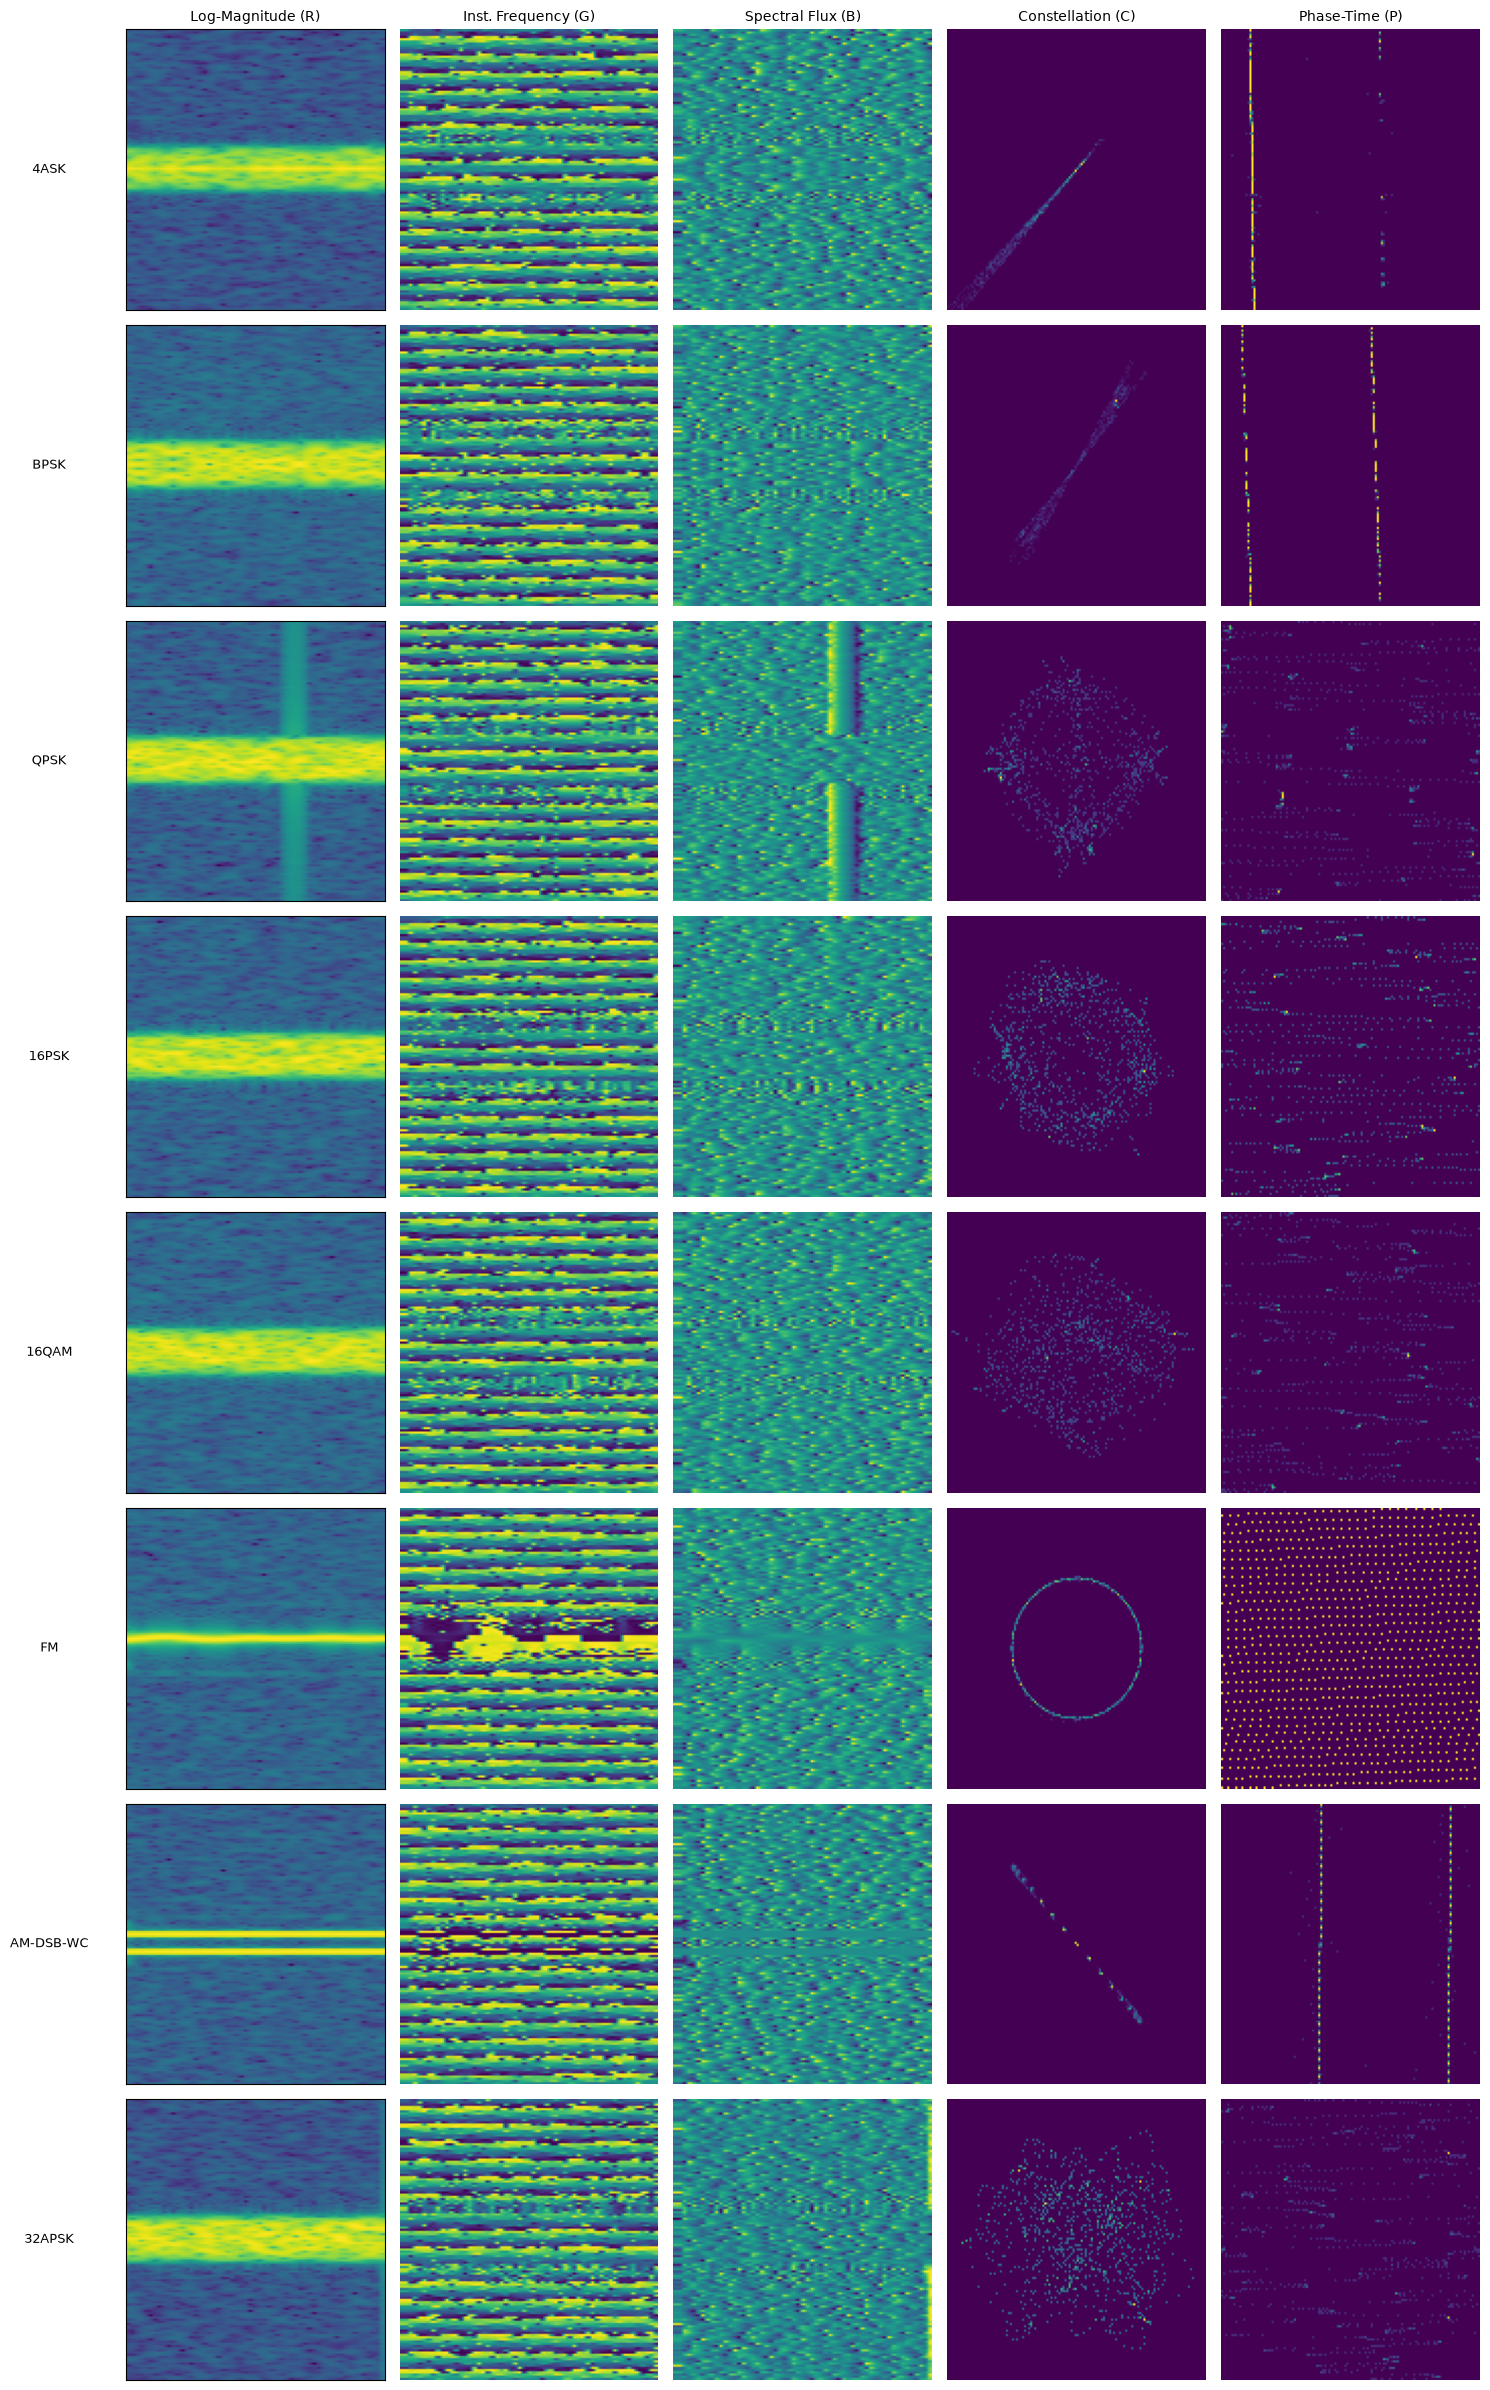

In [ ]:
# ------------------------------------------------------------------
# SPECTROGRAM VISUALIZATION — All 5 Channels per Modulation Class
# ------------------------------------------------------------------

CHANNEL_LABELS = ["Log-Magnitude (R)", "Inst. Frequency (G)", "Spectral Flux (B)",
                  "Constellation (C)", "Phase-Time (P)"]
n_classes = len(selected_ids)

fig, axes = plt.subplots(n_classes, 5, figsize=(15, 3 * n_classes))

for cls in range(n_classes):
    high_snr_indices = np.where((y_int == cls) & (snr >= 28))[0]
    j = high_snr_indices[0] if len(high_snr_indices) > 0 else np.where(y_int == cls)[0][0]

    for ch in range(5):
        ax = axes[cls, ch]
        s = to_spectrogram(X_iq[j])[np.newaxis]  # (1, H, W, 5)
        ax.imshow(np.asarray(keras.ops.image.resize(s, (IMG_SIZE, IMG_SIZE)))[0, :, :, ch], aspect='auto', origin='lower', cmap='viridis')
        ax.axis('off')
        if cls == 0:
            ax.set_title(CHANNEL_LABELS[ch], fontsize=10)
        if ch == 0:
            # ylabel places the class name to the left of the row
            ax.set_ylabel(selected_modulation_classes[cls], fontsize=9,
                          rotation=0, labelpad=55, va='center')
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])

plt.tight_layout()
plt.show()

### Result (Stage 2) {-}

The final preprocessing pipeline creates a 128×128 five-channel feature tensor on demand for each I/Q frame. The channels are log-magnitude STFT, instantaneous frequency, spectral flux, constellation density, and phase-time density. Visual checks show clear structure for analogue and low-order schemes, while the added geometry channels provide the information needed to distinguish the closely related digital classes. The notebook displays these numerical feature maps separately; they are not ordinary RGB photographs.

## Baseline CNN and training (Stage 3) {-}

### Build macro-averaged F1 Score metric

keras.metrics.F1Score is a built-in Keras stateful metric that computes the harmonic mean of precision and recall. Setting average='macro' weights every class equally regardless of how many samples it has — a rare class confused with a similar one penalises the score just as much as a common one. It accumulates per-class TP, FP, and FN across all batches in an epoch, then computes the final score in result() and clears state in reset_state() before the next epoch, following the standard Keras stateful-metric contract.

In [26]:
metrics=[keras.metrics.F1Score(average='macro', name='macro_f1')]

In [27]:
# ------------------------------------------------------------------
# BASELINE CNN ARCHITECTURE
# ------------------------------------------------------------------

# padding='same' preserves spatial dimensions so no pooling adjustment is needed.
def residual_block(x, filters):
    shortcut = layers.Conv2D(filters, 1, padding='same')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    return layers.Activation('relu')(layers.Add()([x, shortcut]))

def build_baseline_cnn(input_shape, n_classes):

    # Define the Input Layer
    inputs = keras.Input(shape=input_shape)
    
    # Convolutional layer. 16 filters, each scanning 3x3 pixel areas.
    # 'relu' lets the network make yes/no decisions so it can understand 
    # complicated features like edges and shapes, not just simple ones.
    x = layers.Conv2D(16, 3, activation='relu')(inputs)
    
    # MaxPooling downsamples images speeding up processing 
    # and helping the network focus on important features 
    # regardless of where they appear in the picture.
    x = layers.MaxPooling2D()(x)
    
    # Middle layer feature extraction 
    # Increasing filters to 32 so the network can find richer, more detailed patterns
    # as it gets deeper and understands more about what it's seeing.
    x = layers.Conv2D(32, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    
    # Deep layer feature extraction
    # Bumping up to 64 filters to detect the most complex, high-level features
    # to recognize full object parts rather than simple shapes.
    x = layers.Conv2D(64, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    # Residual block: helps the network learn better by allowing it to skip layers if needed.
    x = residual_block(x, 64)          

    # 4th block reduces 14×14 spatial map (from 128px input) to 6×6 before flattening.
    x = layers.Conv2D(128, 3, activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    
    # Dense head classification
    # Flatten reshapes all those 2D feature maps into a single long list 
    # so the final prediction layers can read them easily.
    x = layers.Flatten()(x)

    # Dropout randomly turns off 10% of the neurons during training,
    # which helps the model generalize better and not memorize the training data.
    x = layers.Dropout(0.1)(x)   
    
    # Single dense layer with 256 neurons squeezes all the features together,
    # mixing and combining them so the model can make its final prediction.
    x = layers.Dense(256, activation='relu')(x)
    
    # Output layer. One neuron for each modulation class, using 'softmax' activation.
    # Softmax turns raw scores into probabilities that all add up to 100%.
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    
    # Create the model instance linking inputs to outputs.
    model = keras.Model(inputs, outputs, name="baseline_cnn")
    
    # Set up how the model will train.
    # Adam optimizer: Automatically adjusts learning speed, starts at a recommended default (Chollet and Watson, 2026).
    # Categorical crossentropy: Measures how wrong the guesses are across multiple categories.
    # Accuracy: Tracks what % of predictions the model gets right.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalFocalCrossentropy(gamma=2.0),
        # Macro average weights each class equally, penalising confusion between similar classes.
        metrics=metrics
    )
    
    return model

# Instantiate the model dynamically based on dataset's
# image shape and 8 unique modulation classes selected.
model = build_baseline_cnn((IMG_SIZE, IMG_SIZE, 5), len(selected_ids))

# ------------------------------------------------------------------
# EXECUTION: Evaluate model architecture summary
# ------------------------------------------------------------------

model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 126, 126,  │        736 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 63, 63,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 61, 61,    │      4,640 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 30, 30,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 28, 28,    │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_6[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │     36,928 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 14, 14,    │      4,160 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 14, 14,    │          0 │ conv2d_9[0][0],   │
│                     │ 64)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 14, 14,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 12, 12,    │     73,856 │ activation[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 6, 6, 128) │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 4608)      │          0 │ max_pooling2d_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4608)      │          0 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │  1,179,904 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │      2,056 │ dense_2[0][0]   

 Total params: 1,357,704 (5.18 MB)

 Trainable params: 1,357,704 (5.18 MB)

 Non-trainable params: 0 (0.00 B)

### Train with callbacks (Step 7) {-}

Step 7 trains the custom CNN in a single phase. Early stopping monitors validation macro-F1 with patience 5 and restores the best weights. A best-only checkpoint records the strongest validation result, while ReduceLROnPlateau monitors the same metric with patience 4 and a minimum learning rate of 1×10⁻⁶. Only training and validation splits are used; the test set remains untouched until Stage 4 evaluation.

In [28]:
# -----------------------------------------------------------------------------
# TRAINING
# -----------------------------------------------------------------------------

callbacks = [
    # Early Stopping
    # Watches validation loss during training. If it doesn't 
    # get better for 8 rounds in a row, training ends right away.
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1',     # Watch the validation macro F1 score metric
        patience=5,                 # Wait 5 epochs before stopping
        mode='max',                 # Monitor for maximum since I want to maximize macro F1 score
        restore_best_weights=True   # Roll back to the best epoch's weights
    ),

    # Best-Only Checkpointing
    # Saves the model's weights only when 'val_macro_f1' improves.
    # This ensures the weights file 'baseline_cnn.weights.h5' 
    # always contains the single best performing version seen during training.
    keras.callbacks.ModelCheckpoint(
        filepath='baseline_cnn.weights.h5', 
        monitor='val_macro_f1', 
        save_best_only=True,     # Only overwrite if performance gets better
        save_weights_only=True   # Save only weights to save disk space
    ),

    # Learning Rate Reduction on Plateau
    # If validation macro F1 score stops improving for 4 epochs, cut the learning rate in half.
    # Smaller steps let the model carefully fine-tune when it's stuck and can't improve.
    # 'min_lr=2.5e-5' stops the rate from dropping so low it practically freezes.
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_macro_f1', 
        factor=0.5,                 # Reduce LR by 50%
        patience=4,                 # Trigger reduction after 4 epochs of no improvement
        mode='max',                 # Monitor for maximum since I want to maximize macro F1 score
        min_lr=1e-6                 # Minimum learning rate allowed
    ),
]

# -----------------------------------------------------------------------------
# EXECUTION: Model Training
# -----------------------------------------------------------------------------

# ----------------------------------------------------------------------
# NOTE: The test set (idx_test) is completely untouched here. It is reserved 
# solely for the final unbiased evaluation after all hyperparameter tuning is done.
# ----------------------------------------------------------------------

training_inputs = SpectrogramSequence(X_iq[idx_train], y_oh[idx_train])
validation_inputs = SpectrogramSequence(X_iq[idx_val], y_oh[idx_val])

history = model.fit(
    training_inputs,                                # Training inputs
    validation_data=validation_inputs,              # Validation split (monitored by callbacks)
    epochs=40,                                      # Maximum possible epochs (EarlyStopping may stop earlier)
    callbacks=callbacks,                            # Attach safety callbacks
    verbose=2                                       # Print training progress per epoch
)

Epoch 1/40
595/595 - 155s - 260ms/step - loss: 0.1282 - macro_f1: 0.6574 - val_loss: 0.0331 - val_macro_f1: 0.8898 - learning_rate: 0.0010
Epoch 2/40
595/595 - 171s - 287ms/step - loss: 0.0269 - macro_f1: 0.9066 - val_loss: 0.0230 - val_macro_f1: 0.9227 - learning_rate: 0.0010
Epoch 3/40
595/595 - 163s - 274ms/step - loss: 0.0227 - macro_f1: 0.9206 - val_loss: 0.0210 - val_macro_f1: 0.9273 - learning_rate: 0.0010
Epoch 4/40
595/595 - 210s - 353ms/step - loss: 0.0222 - macro_f1: 0.9246 - val_loss: 0.0190 - val_macro_f1: 0.9312 - learning_rate: 0.0010
Epoch 5/40
595/595 - 199s - 335ms/step - loss: 0.0173 - macro_f1: 0.9387 - val_loss: 0.0199 - val_macro_f1: 0.9372 - learning_rate: 0.0010
Epoch 6/40
595/595 - 184s - 310ms/step - loss: 0.0158 - macro_f1: 0.9440 - val_loss: 0.0215 - val_macro_f1: 0.9289 - learning_rate: 0.0010
Epoch 7/40
595/595 - 238s - 400ms/step - loss: 0.0163 - macro_f1: 0.9435 - val_loss: 0.0189 - val_macro_f1: 0.9351 - learning_rate: 0.0010
Epoch 8/40
595/595 - 177s -

### Training curves (Step 8) {-}

Step 8 plots macro-F1 and loss to identify convergence and overfitting. The custom CNN trains in a single phase, so the curves are continuous. A widening train–validation gap indicates overfitting; early stopping restores the best validation macro-F1 checkpoint.

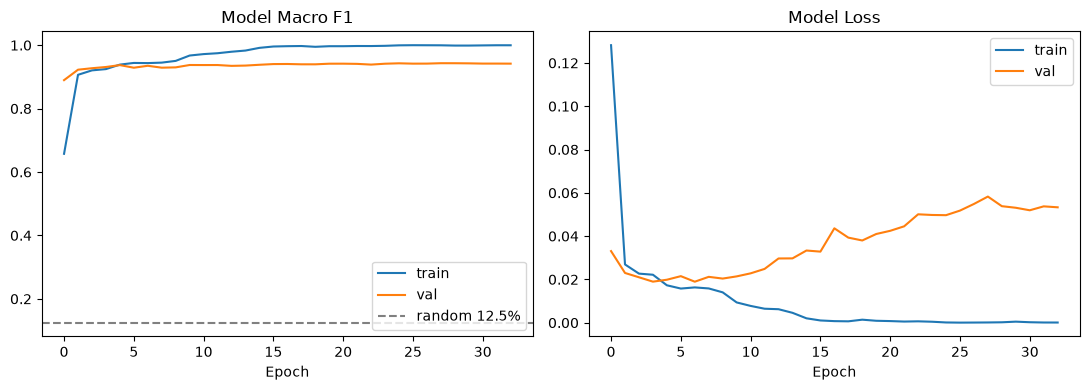

In [32]:
# -----------------------------------------------------------------------------
# TRAINING HISTORY VISUALIZATION
# -----------------------------------------------------------------------------

h = history.history

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

# Macro F1 Curve
a1.plot(h['macro_f1'],     label='train')
a1.plot(h['val_macro_f1'], label='val')

# Random-guess F1 baseline for n equal classes.
a1.axhline(1 / len(selected_ids), ls='--', c='grey', label='random 12.5%')

a1.set_title('Model Macro F1')
a1.set_xlabel('Epoch')
a1.legend(loc='lower right')

# Loss Curve
a2.plot(h['loss'],     label='train')
a2.plot(h['val_loss'], label='val')

a2.set_title('Model Loss')
a2.set_xlabel('Epoch')
a2.legend(loc='upper right')

# ------------------------------------------------------------------
# EXECUTION: Render training history plots
# ------------------------------------------------------------------

plt.tight_layout()
plt.show()

### Result (Stage 3) {-}

The final custom CNN trains in a single phase on 19,040 SNR ≥ −2 dB samples. Its four convolutional blocks, residual block, and dense head process the five-channel 128×128 feature tensors without the ImageNet domain-mismatch penalty found in the transfer-learning runs. Training curves show whether the regularised custom model converges and whether a train–validation gap develops.

## SNR balanced evaluation (Stage 4) {-}

### Evaluate against the random floor and confusion matrix (Step 9) {-}

Step 9 evaluates test accuracy against the 12.5% threshold to verify statistical power, performed only on the held-out test set (Chollet and Watson, 2026). A confusion matrix then reveals the hardest classification pairs. Published analysis predicts confusion among same-family digital schemes at low SNR (Abd-Elaziz et al., 2023; Nasir et al., 2025).

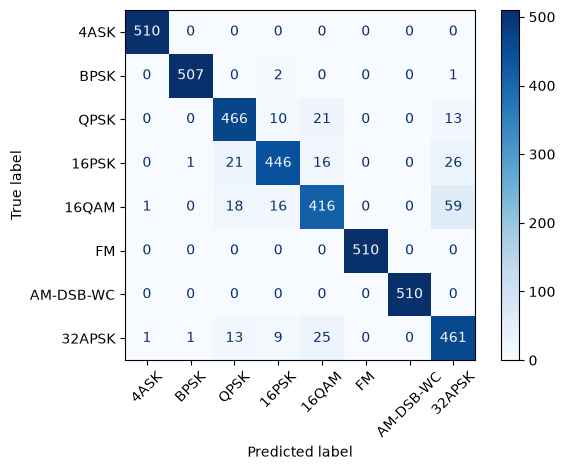

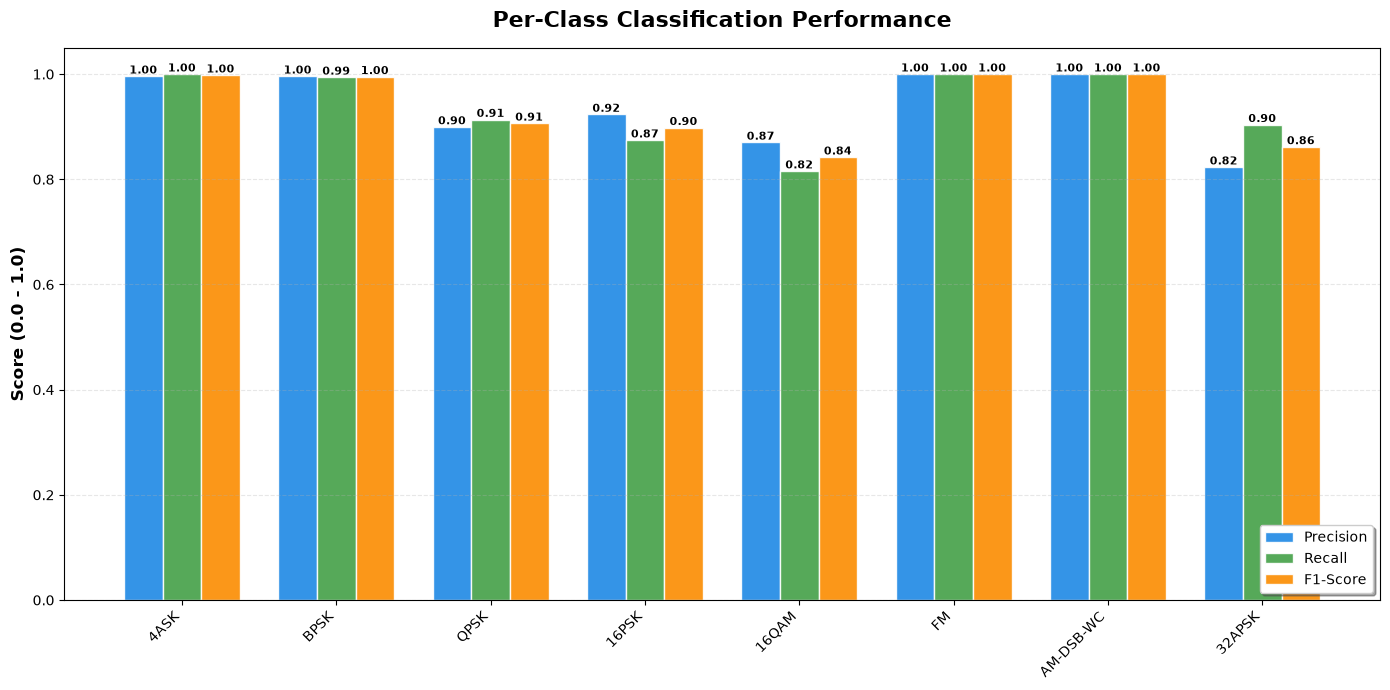

=== EVALUATION SUMMARY ===
Test Accuracy : 0.9377  |  Loss: 0.0573  |  Chance: 0.1250
Lift over chance: 7.50x

Class          Prec    Rec     F1      N
------------------------------------------
4ASK          0.996  1.000  0.998    510
BPSK          0.996  0.994  0.995    510
QPSK          0.900  0.914  0.907    510
16PSK         0.923  0.875  0.898    510
16QAM         0.870  0.816  0.842    510
FM            1.000  1.000  1.000    510
AM-DSB-WC     1.000  1.000  1.000    510
32APSK        0.823  0.904  0.862    510

Top-8 confusions (true → pred : count):
  16QAM      → 32APSK     : 59
  16PSK      → 32APSK     : 26
  32APSK     → 16QAM      : 25
  QPSK       → 16QAM      : 21
  16PSK      → QPSK       : 21
  16QAM      → QPSK       : 18
  16PSK      → 16QAM      : 16
  16QAM      → 16PSK      : 16


In [33]:
# -----------------------------------------------------------------------------
# EVALUATION ON TEST SET
# -----------------------------------------------------------------------------
test_inputs = SpectrogramSequence(X_iq[idx_test], y_oh[idx_test])

test_loss, test_acc = model.evaluate(
    test_inputs, 
    verbose=0  # Silent mode to keep output clean
)

# Prepare ground truth labels
y_true = y_int[idx_test]

# Predict class probabilities and take argmax to get predicted class indices
y_pred = model.predict(test_inputs, verbose=0).argmax(1)

# Compute the raw confusion matrix counts
cm = confusion_matrix(y_true, y_pred)

# Visualize the matrix to spot diagonal dominance (correct predictions) 
# and off-diagonal hotspots (systematic errors).
# 'selected_modulation_classes' ensures the axis labels match our dataset.
ConfusionMatrixDisplay(
    cm, 
    display_labels=selected_modulation_classes
).plot(
    xticks_rotation=45,  # Rotate labels for readability
    cmap='Blues'         # Blue colormap highlights intensity
)

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# METRICS PREPARATION
# -----------------------------------------------------------------------------

# Evaluate Model
test_loss, test_acc = model.evaluate(test_inputs, verbose=0)
floor = 1 / len(selected_ids)

# Prepare Labels and Predictions
y_true = y_int[idx_test]
y_pred = model.predict(test_inputs, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_true, y_pred)
labels_list = list(selected_modulation_classes)
n_classes = len(labels_list)

# Calculate Per-Class Metrics (Precision, Recall, F1)
metrics_data = []
for i in range(n_classes):
    support = int(cm[i].sum())
    tp = int(cm[i, i])
    fp = int(cm[:, i].sum()) - tp
    fn = int(cm[i].sum()) - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_score  = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    metrics_data.append({
        'class': labels_list[i], 
        'support': support, 
        'precision': precision, 
        'recall': recall, 
        'f1': f1_score
    })

# Identify Top 8 Worst Confusions
confusions = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j and cm[i, j] > 0:
            confusions.append((labels_list[i], labels_list[j], int(cm[i, j])))

# Sort by count descending and take top 8
confusions.sort(key=lambda x: x[2], reverse=True)
worst_pairs = confusions[:8]

# Per-Class Classification Metrics
fig_metrics = plt.figure(figsize=(14, 7))
ax_metrics = fig_metrics.add_subplot()

x = np.arange(len(labels_list))
width = 0.25

# Extract metrics for plotting
precisions = [m['precision'] for m in metrics_data]
recalls    = [m['recall'] for m in metrics_data]
f1_scores  = [m['f1'] for m in metrics_data]

# Create grouped bar chart for Precision, Recall, and F1-Score
b1 = ax_metrics.bar(x - width, precisions, width, label='Precision', color='#1E88E5', alpha=0.9, edgecolor='white')
b2 = ax_metrics.bar(x, recalls, width, label='Recall', color='#43A047', alpha=0.9, edgecolor='white')
b3 = ax_metrics.bar(x + width, f1_scores, width, label='F1-Score', color='#FB8C00', alpha=0.9, edgecolor='white')

# Set axis labels, title, and ticks for clarity
ax_metrics.set_ylabel('Score (0.0 - 1.0)', fontsize=12, fontweight='bold')
ax_metrics.set_title('Per-Class Classification Performance', fontsize=16, fontweight='bold', pad=15)
ax_metrics.set_xticks(x)
ax_metrics.set_xticklabels(labels_list, rotation=45, ha='right', fontsize=10)
ax_metrics.set_ylim(0, 1.05)
ax_metrics.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax_metrics.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels on bars
for bars in [b1, b2, b3]:
    for rect in bars:
        h = rect.get_height()
        if h > 0:
            ax_metrics.text(rect.get_x() + rect.get_width()/2., h, f'{h:.2f}', 
                            ha='center', va='bottom', fontsize=8, fontweight='bold')
            
# ------------------------------------------------------------------
# EXECUTION: Render Per-Class Metrics Bar Chart
# ------------------------------------------------------------------

plt.tight_layout()
plt.show(fig_metrics)

# ------------------------------------------------------------------
# AGENT-READABLE TEXT SUMMARY (no plots)
# ------------------------------------------------------------------

lines = []
lines.append("=== EVALUATION SUMMARY ===")
lines.append(f"Test Accuracy : {test_acc:.4f}  |  Loss: {test_loss:.4f}  |  Chance: {floor:.4f}")
lines.append(f"Lift over chance: {test_acc / floor:.2f}x\n")

lines.append(f"{'Class':<12} {'Prec':>6} {'Rec':>6} {'F1':>6} {'N':>6}")
lines.append("-" * 42)
for m in metrics_data:
    lines.append(f"{m['class']:<12} {m['precision']:>6.3f} {m['recall']:>6.3f} {m['f1']:>6.3f} {m['support']:>6}")

lines.append(f"\nTop-{len(worst_pairs)} confusions (true → pred : count):")
for true_cls, pred_cls, count in worst_pairs:
    lines.append(f"  {true_cls:<10} → {pred_cls:<10} : {count}")

summary = "\n".join(lines)
print(summary)

### Result (Step 9) {-}

The final five-channel CNN is evaluated on the SNR ≥ −2 dB held-out test set (4,080 samples) against the 12.5% random-guess floor and the 49.47% full-range baseline. Because the final test set excludes the lowest-SNR samples, its result is not directly comparable with the all-SNR baseline without accounting for the different data regimes. The confusion matrix tests whether the constellation and phase-time channels reduce the digital-class overlap found in the earlier STFT representations.

### Accuracy versus SNR (Step 10) {-}

Step 10 plots final-model accuracy across the retained SNR levels. The held-out test set is restricted to SNR ≥ −2 dB, so this curve must be interpreted separately from the earlier full-range baseline. The confusion matrix and per-class precision, recall, and F1 results provide complementary evidence for digital-class separation.

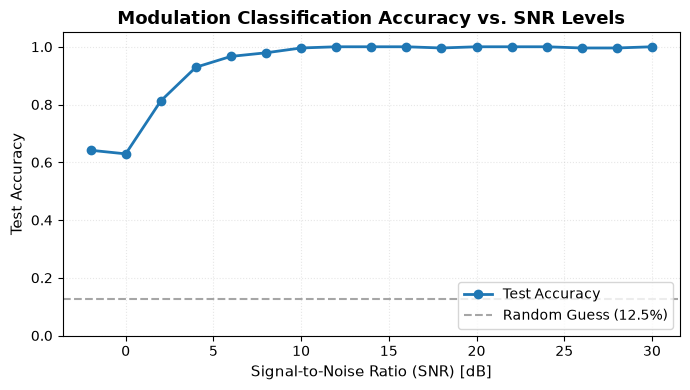

In [ ]:
# -----------------------------------------------------------------------------
# SNR ANALYSIS
# -----------------------------------------------------------------------------

# Extract the SNR value for each sample in the filtered final-model test set
snr_test = snr_filt[pos_test]

# Identify retained SNR levels present in the final test data
# (−2, 0, ..., 30 dB)
levels = np.unique(snr_test)

# Calculate accuracy for each retained SNR level independently
acc_by_snr = [
    (y_pred[snr_test == L] == y_true[snr_test == L]).mean()
    for L in levels
]

# Plot the results
plt.figure(figsize=(7, 4))
plt.plot(
    levels,
    acc_by_snr,
    marker='o',      # Markers make individual points visible
    linewidth=2,     # Thicker line for readability
    label='Test Accuracy'
)

# Draw the baseline (random guessing threshold) for reference.
# If the model dips below this line, it's performing worse than random.
floor = 1 / len(selected_ids)
plt.axhline(floor, ls='--', c='grey', alpha=0.7, label=f'Random Guess ({floor:.1%})')

# Labeling
plt.xlabel('Signal-to-Noise Ratio (SNR) [dB]', fontsize=11)
plt.ylabel('Test Accuracy', fontsize=11)
plt.title('Modulation Classification Accuracy vs. SNR Levels', fontsize=13, fontweight='bold')

# Add grid to improve readability
plt.grid(True, alpha=0.3, linestyle=':')

# Set y-axis limits for better visibility
plt.ylim(bottom=0, top=max(acc_by_snr)*1.05 if acc_by_snr else 1.0)

# ------------------------------------------------------------------
# EXECUTION: Render per SNR vs. Random Accuracy Plot
# ------------------------------------------------------------------

plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Stage 4 Step 10 Result {-}

The final-model SNR curve covers only the retained range from −2 dB to +30 dB. Accuracy starts at approximately 64% at −2 dB, rises above 80% by 2 dB, and reaches approximately 99% above 10 dB. This curve belongs to the five-channel filtered model; the earlier full-range curve belongs to the single-channel baseline and must not be used as the final model's full-range result.